In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from lib import spoti
import json
import os
from typing import List, Dict, Tuple

In [2]:
DATA_PATH = os.path.join("data")

In [3]:
owen = spoti.SpotiUser("owen")
brenda = spoti.SpotiUser("brenda")
arthur = spoti.SpotiUser("arthur")
michelle = spoti.SpotiUser("michelle")
paul = spoti.SpotiUser("paul")
jaslkh = spoti.SpotiUser("jaslkh")
lsirwguhu = spoti.SpotiUser("lsirwguhu")

In [4]:
USERS = [jaslkh, owen, brenda, arthur, michelle, paul, lsirwguhu]

In [5]:
def get_data_path(user: spoti.SpotiUser) -> str:
    return os.path.join(DATA_PATH, f"{user.username}_top_tracks.json")

In [6]:
def simplify_genre(genres: List[str]) -> List[str]:
    for i, genre in enumerate(genres):
        if "rock" in genre: genres[i] = "rock"
        if "pop" in genre: genres[i] = "pop"
        if "rap" in genre: genres[i] = "rap"
        if "hip hop" in genre: genres[i] = "rap"
        if "emo" in genre or "punk" in genre or "screamo" in genre or "hardcore" in genre or "dreamo" in genre or "grunge" in genre: genres[i] = "emo/punk/grunge"
        if "metal" in genre: genres[i] = "metal"
        if "lo-fi" in genre or "chill" in genre or "lofi" in genre: genres[i] = "lo-fi"
        if "indie" in genre: genres[i] = "indie"
        if "french" in genre or "francophone" in genre or "francais" in genre: genres[i] = "french"
        if "house" in genre or "edm" in genre or "electro" in genre or "electronic" in genre: genres[i] = "electronic"
        if "jazz" in genre: genres[i] = "jazz"
        if "classical" in genre: genres[i] = "classical"
        if "r&b" in genre or "soul" in genre: genres[i] = "r&b"
    return list(set(genres))

USERS_DF = []
for user in USERS:
    df = pd.read_json(get_data_path(user), orient="records")
    df["simplified_genres"] = df["genres"].apply(simplify_genre)
    df["username"] = user.username
    USERS_DF.append(df)

df = pd.concat(USERS_DF)

In [7]:
px.pie(df, names="username", title="Number of Liked Tracks per User")

In [8]:
def count_list_column_per_user(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df_count = df.explode(column)
    df_count = df_count.groupby([column, "username"]).count().reset_index()
    df_count = df_count.rename(columns={"id": "count"})
    df_count = df_count[[column, "username", "count"]]
    df_count["count"] = df_count["count"] / df_count.groupby("username")["count"].transform("sum")
    df_count = df_count.sort_values("count", ascending=False)
    return df_count

In [9]:
# Turn dataset into a list of genres
df_count_genre = count_list_column_per_user(df, "simplified_genres")
px.bar(df_count_genre.groupby("username").head(20), x="simplified_genres", y="count", color="username", title="Number of Liked Tracks per Genre", barmode="group")

In [10]:
df["artists_names"] = df["artists"].apply(lambda x: [artist["name"] for artist in x])
df_count_artists = count_list_column_per_user(df, "artists_names")
px.bar(df_count_artists.groupby("username").head(100), x="artists_names", y="count", color="username", title="Number of liked artists per user", barmode="group")

In [11]:
user_top_likes = owen
time_ranges = ["short_term", "medium_term", "long_term"]

top_tracks = df[(df["username"] == user_top_likes.username) & (df["time_range"].isin(time_ranges))] \
    .sort_values("popularity", ascending=False) \
    .sort_values("time_range", ascending=False) \
    .apply(lambda x: f"{x['artists'][0]['name']} - {x['name']} ({x['time_range']})", axis=1) \
    .to_list()

# print("\n".join(top_tracks))

In [12]:
numeric_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness",
    "duration_ms",
]

<Figure size 2000x1000 with 0 Axes>

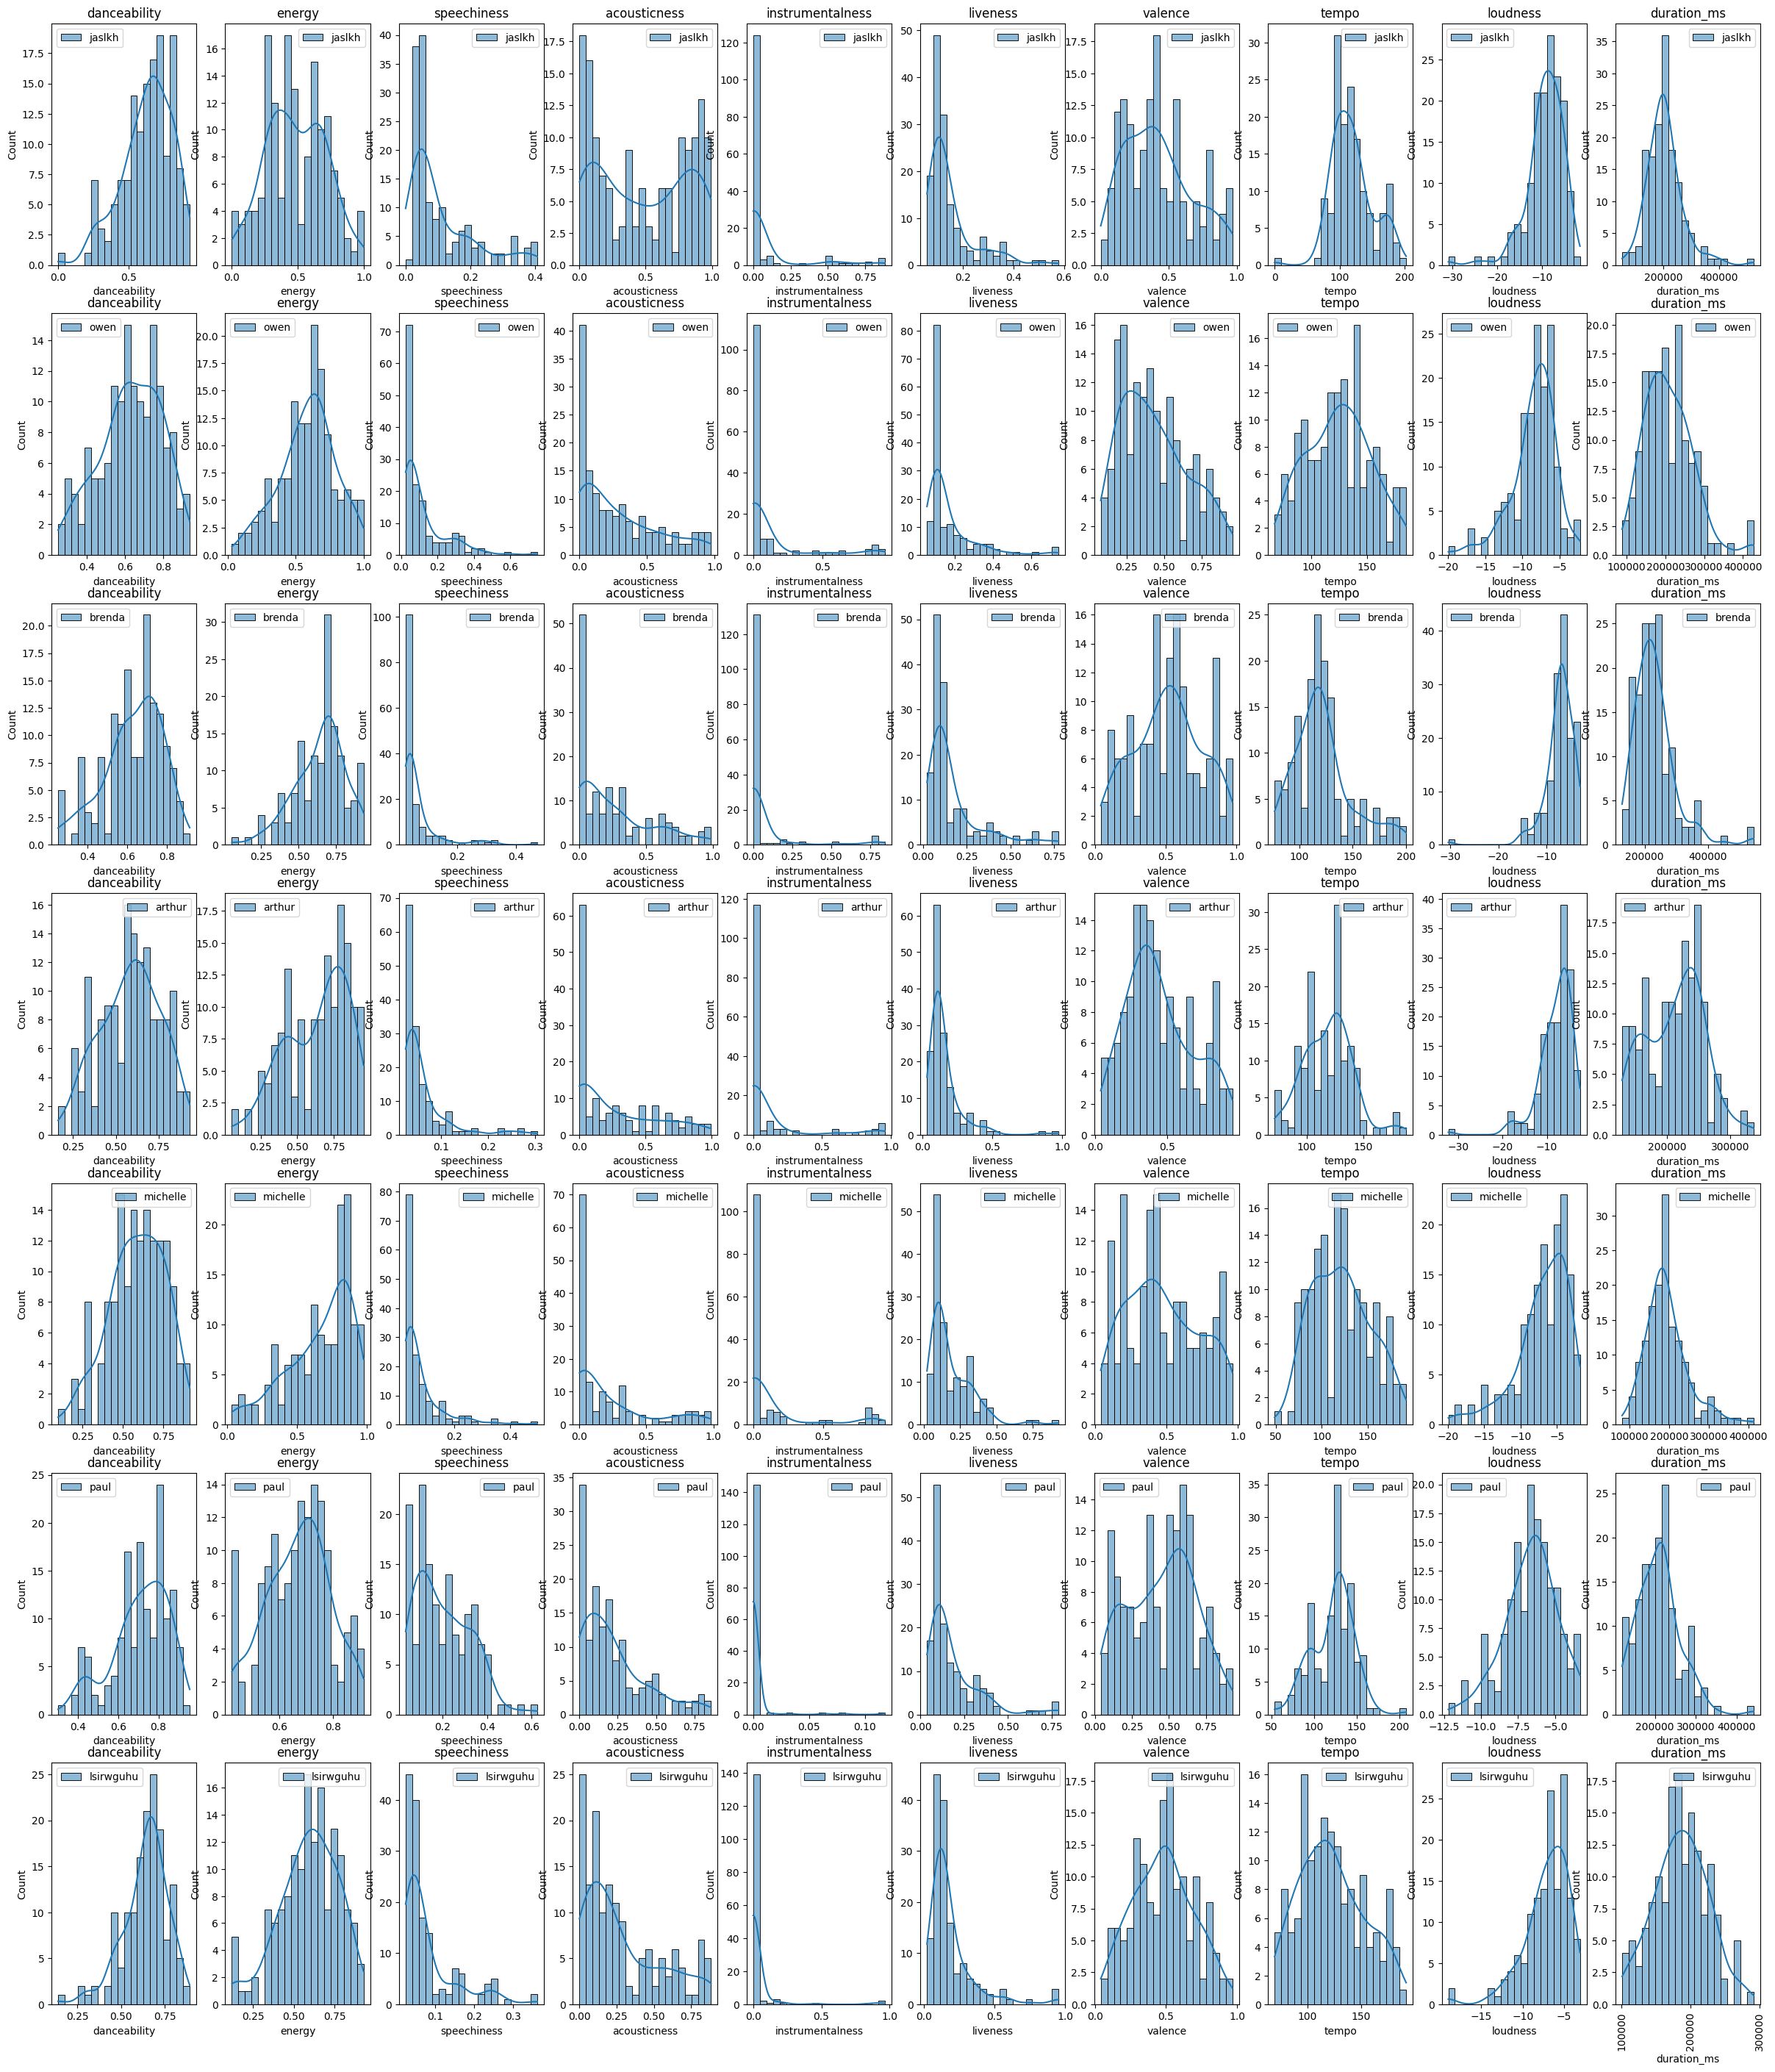

In [13]:
plt.figure(figsize=(20,10))

fig, axs = plt.subplots(len(USERS), len(numeric_features), figsize=(30, len(USERS)*5))

for i, user in enumerate(USERS):
    # Show features distribution for each user
    user_top_tracks = USERS_DF[i]
    for i, feature in enumerate(numeric_features):
        sns.histplot(x=feature, data=user_top_tracks, ax=axs[USERS.index(user), i], bins=20, kde=True, label=user.username)
        axs[USERS.index(user), i].set_title(feature)
        axs[USERS.index(user), i].legend()

plt.legend()
plt.xticks(rotation=90)
plt.show()

<Figure size 2000x1000 with 0 Axes>

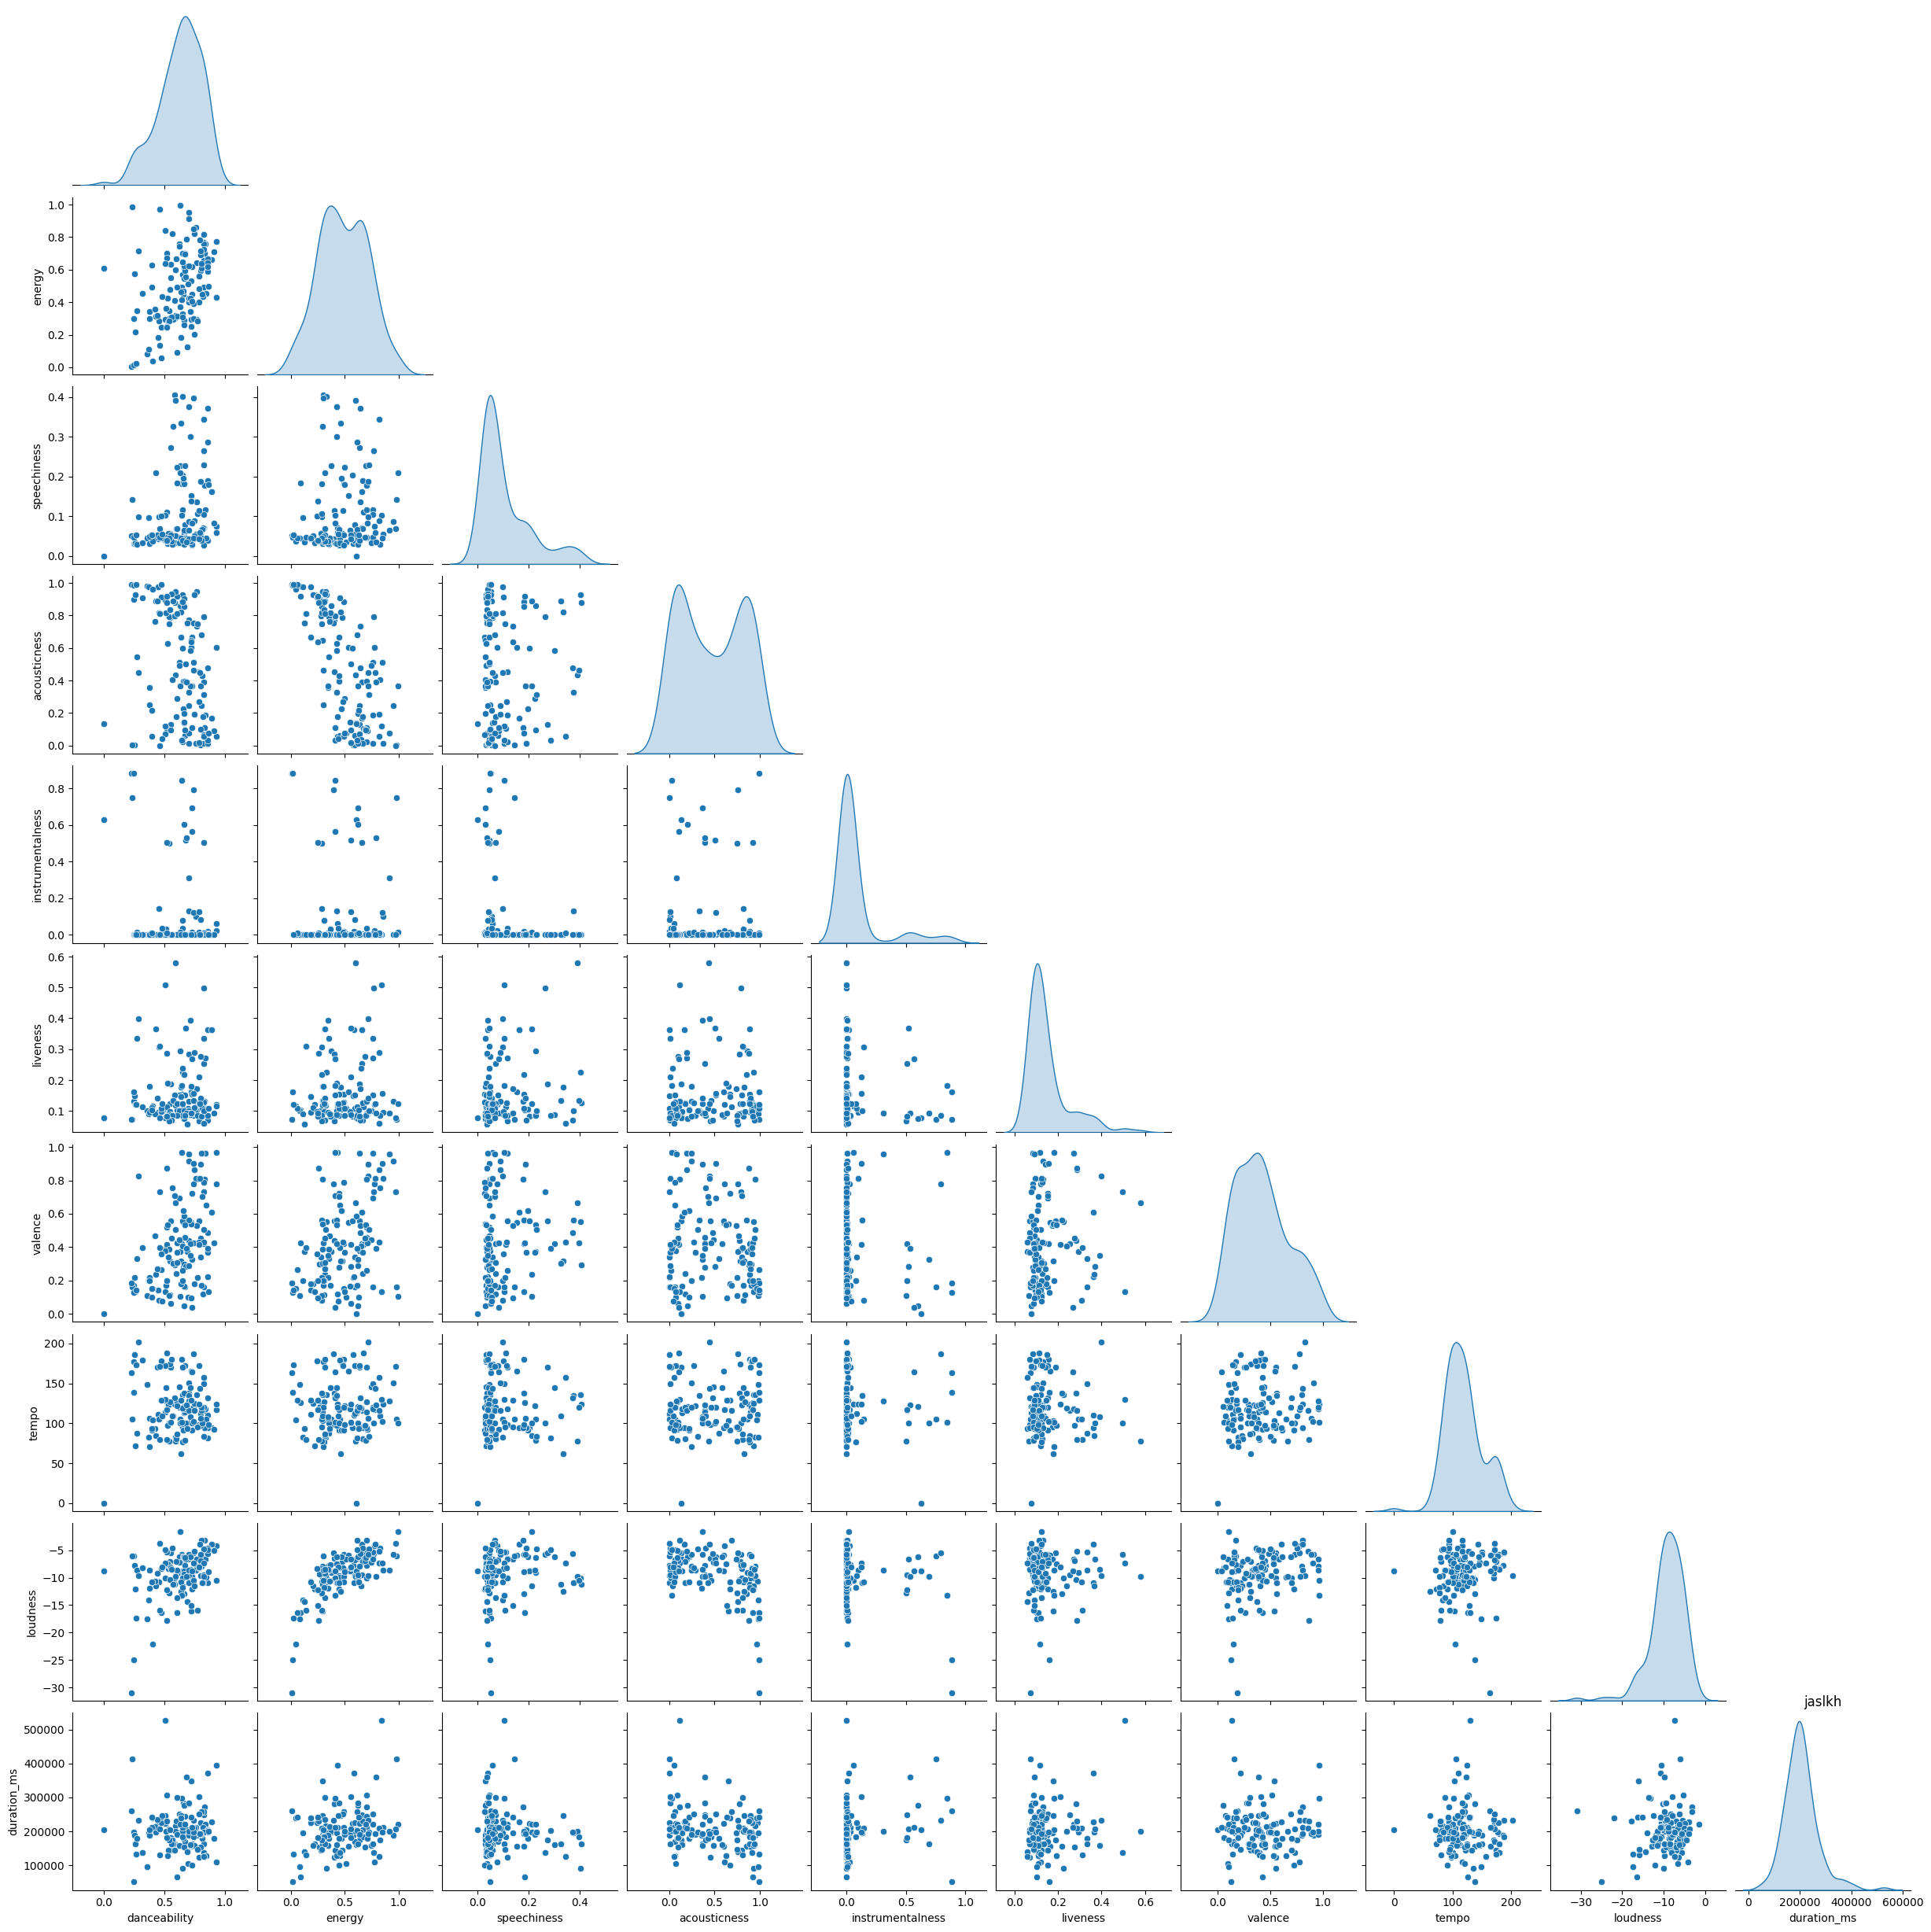

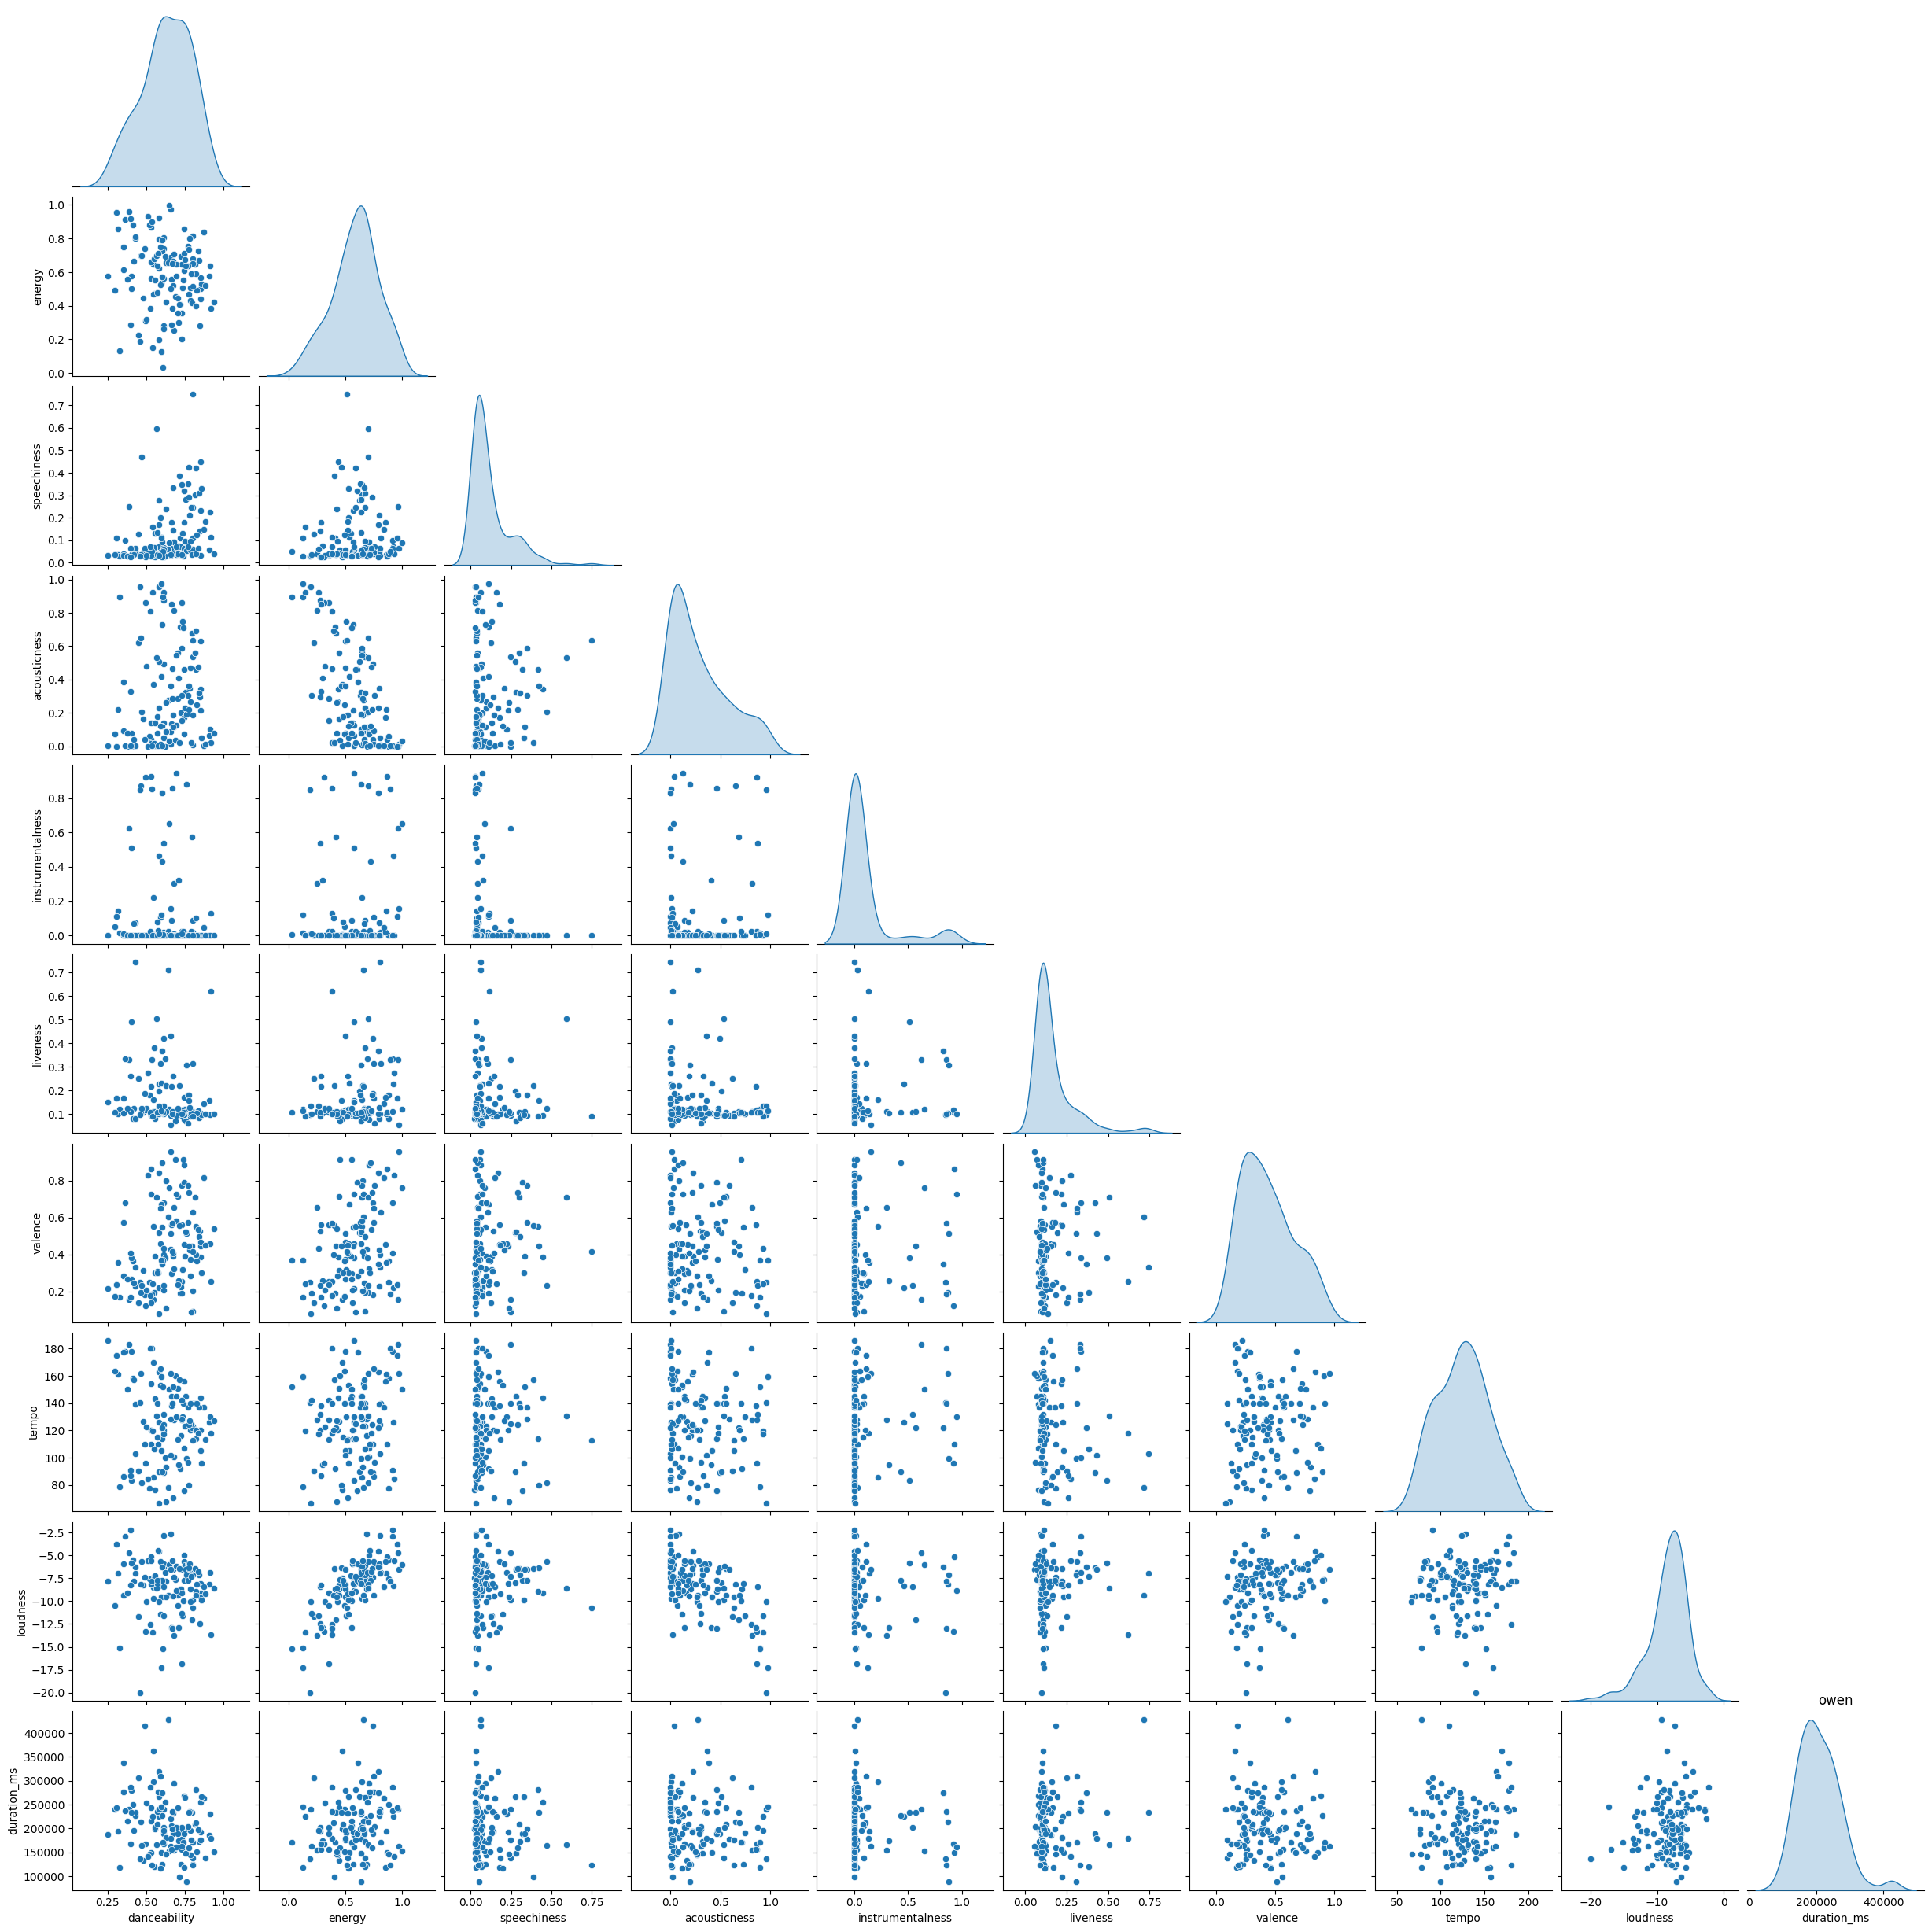

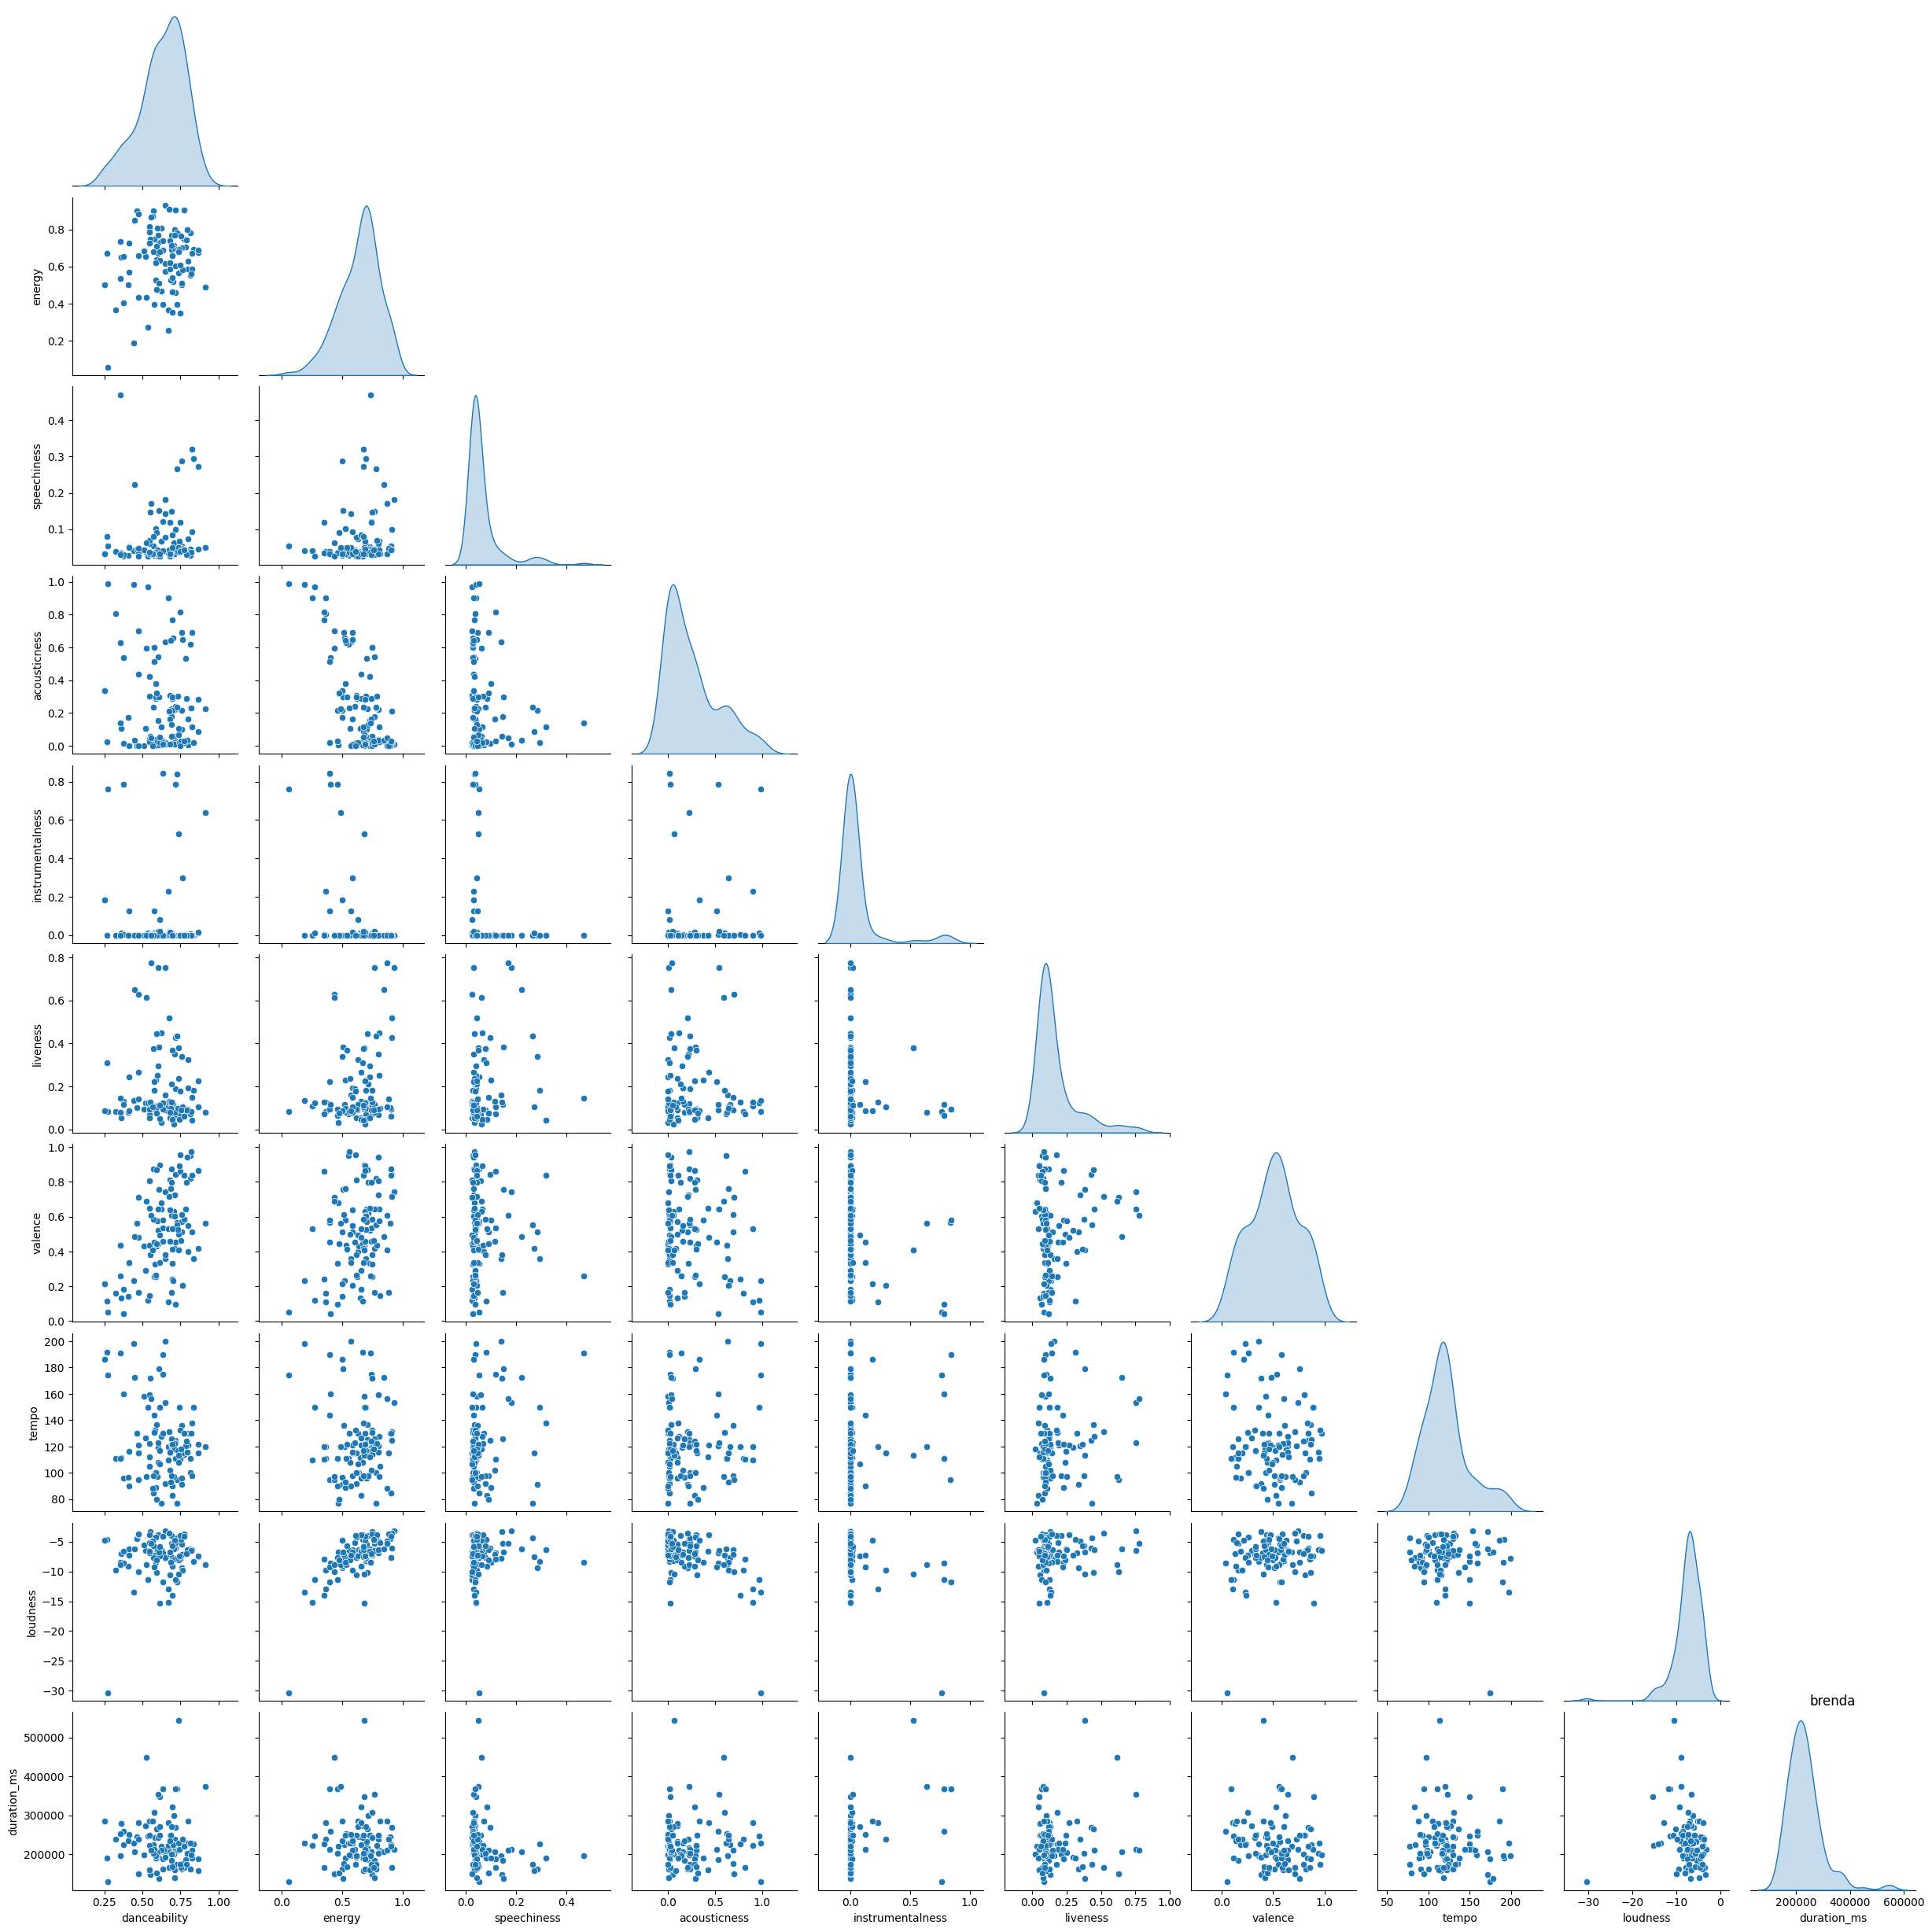

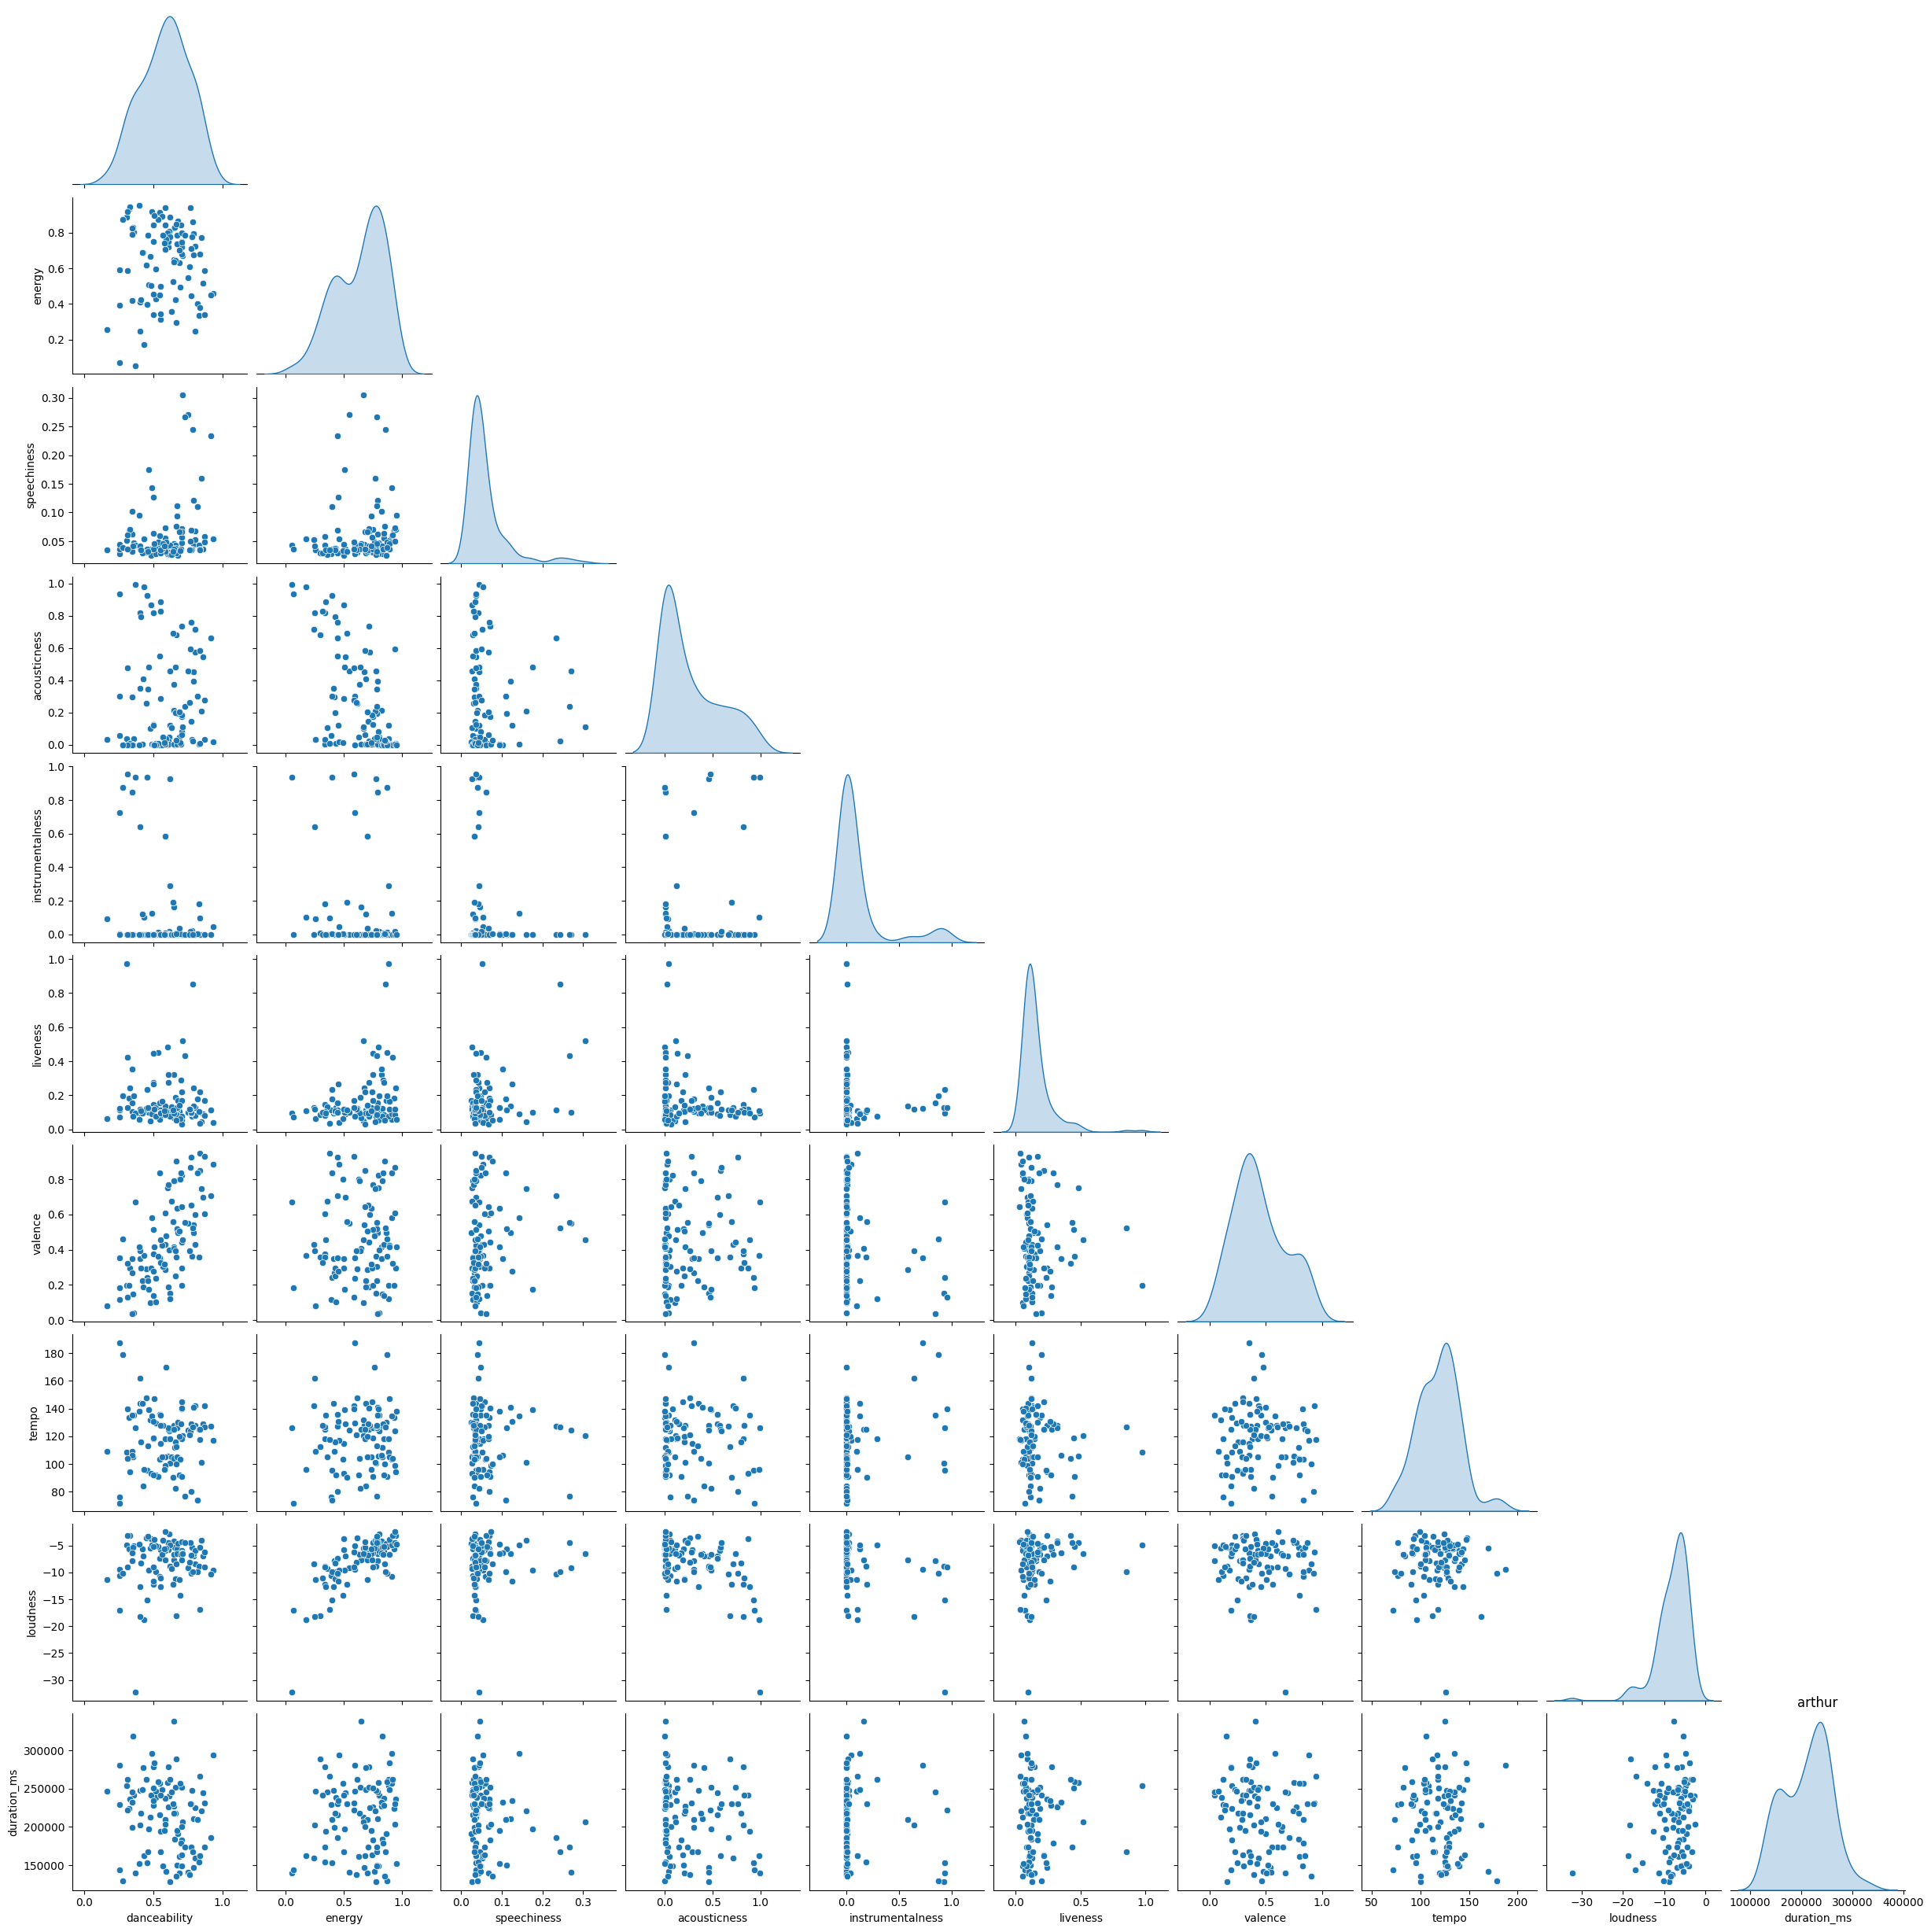

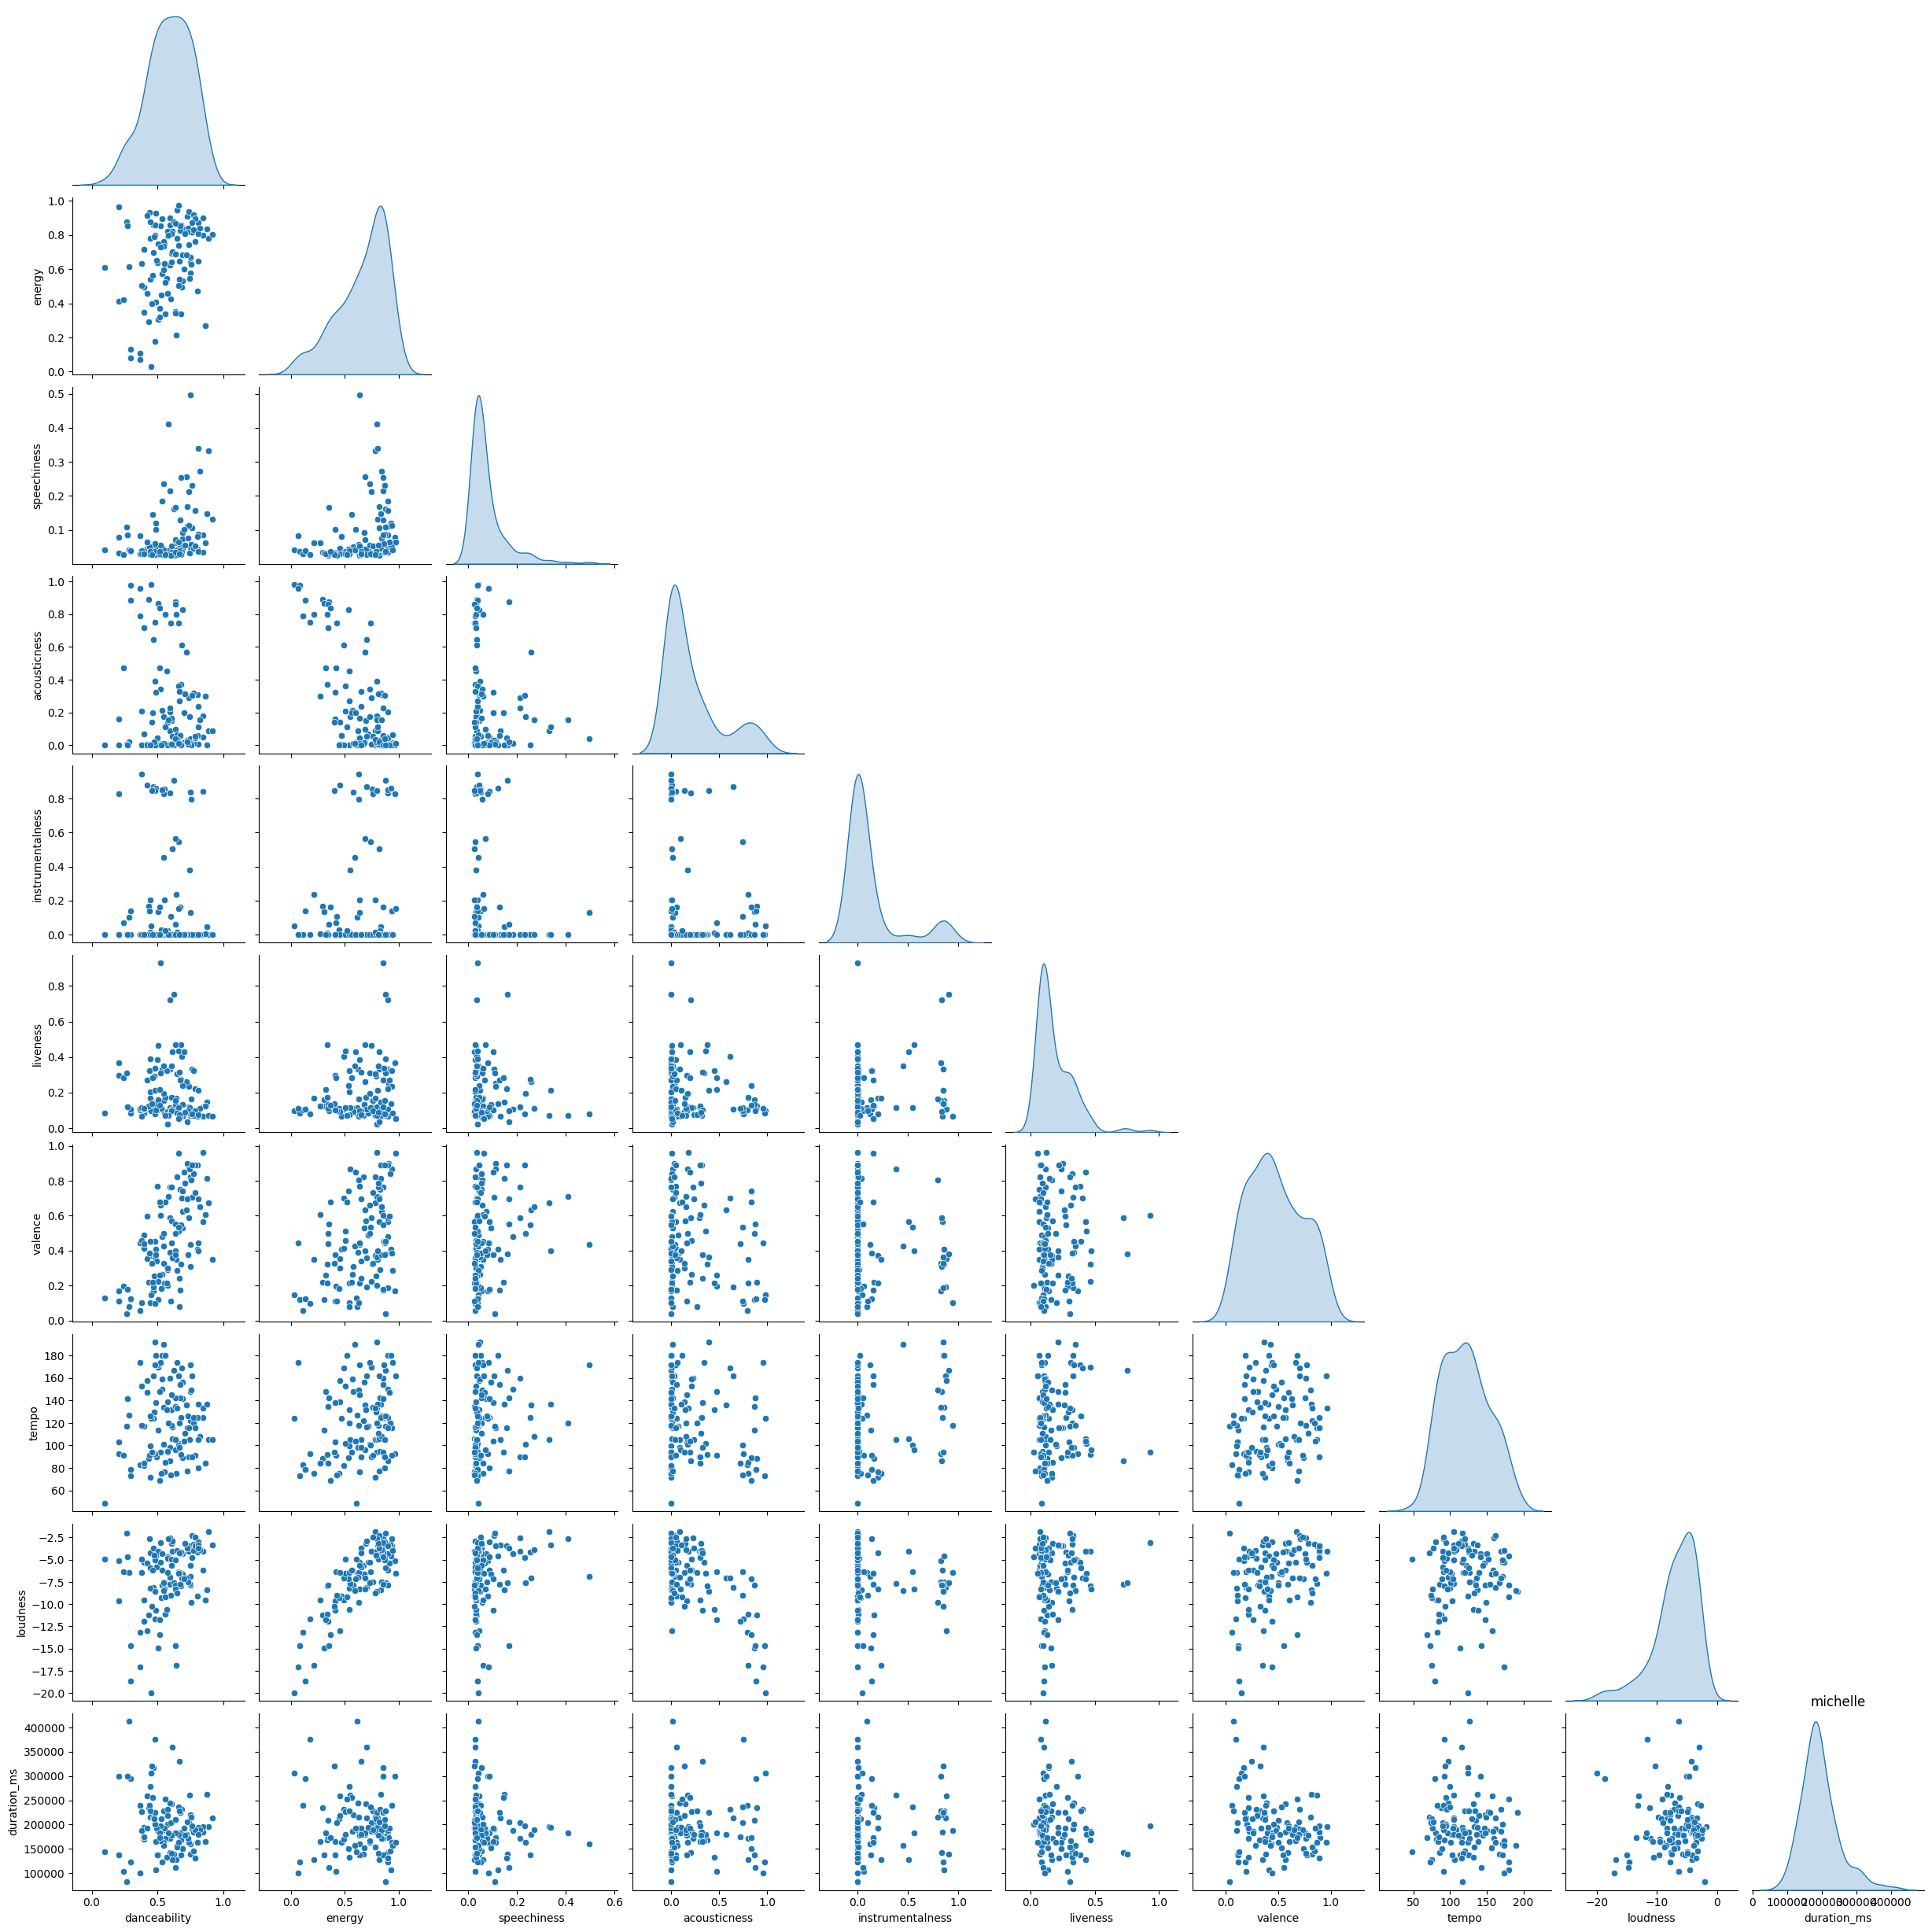

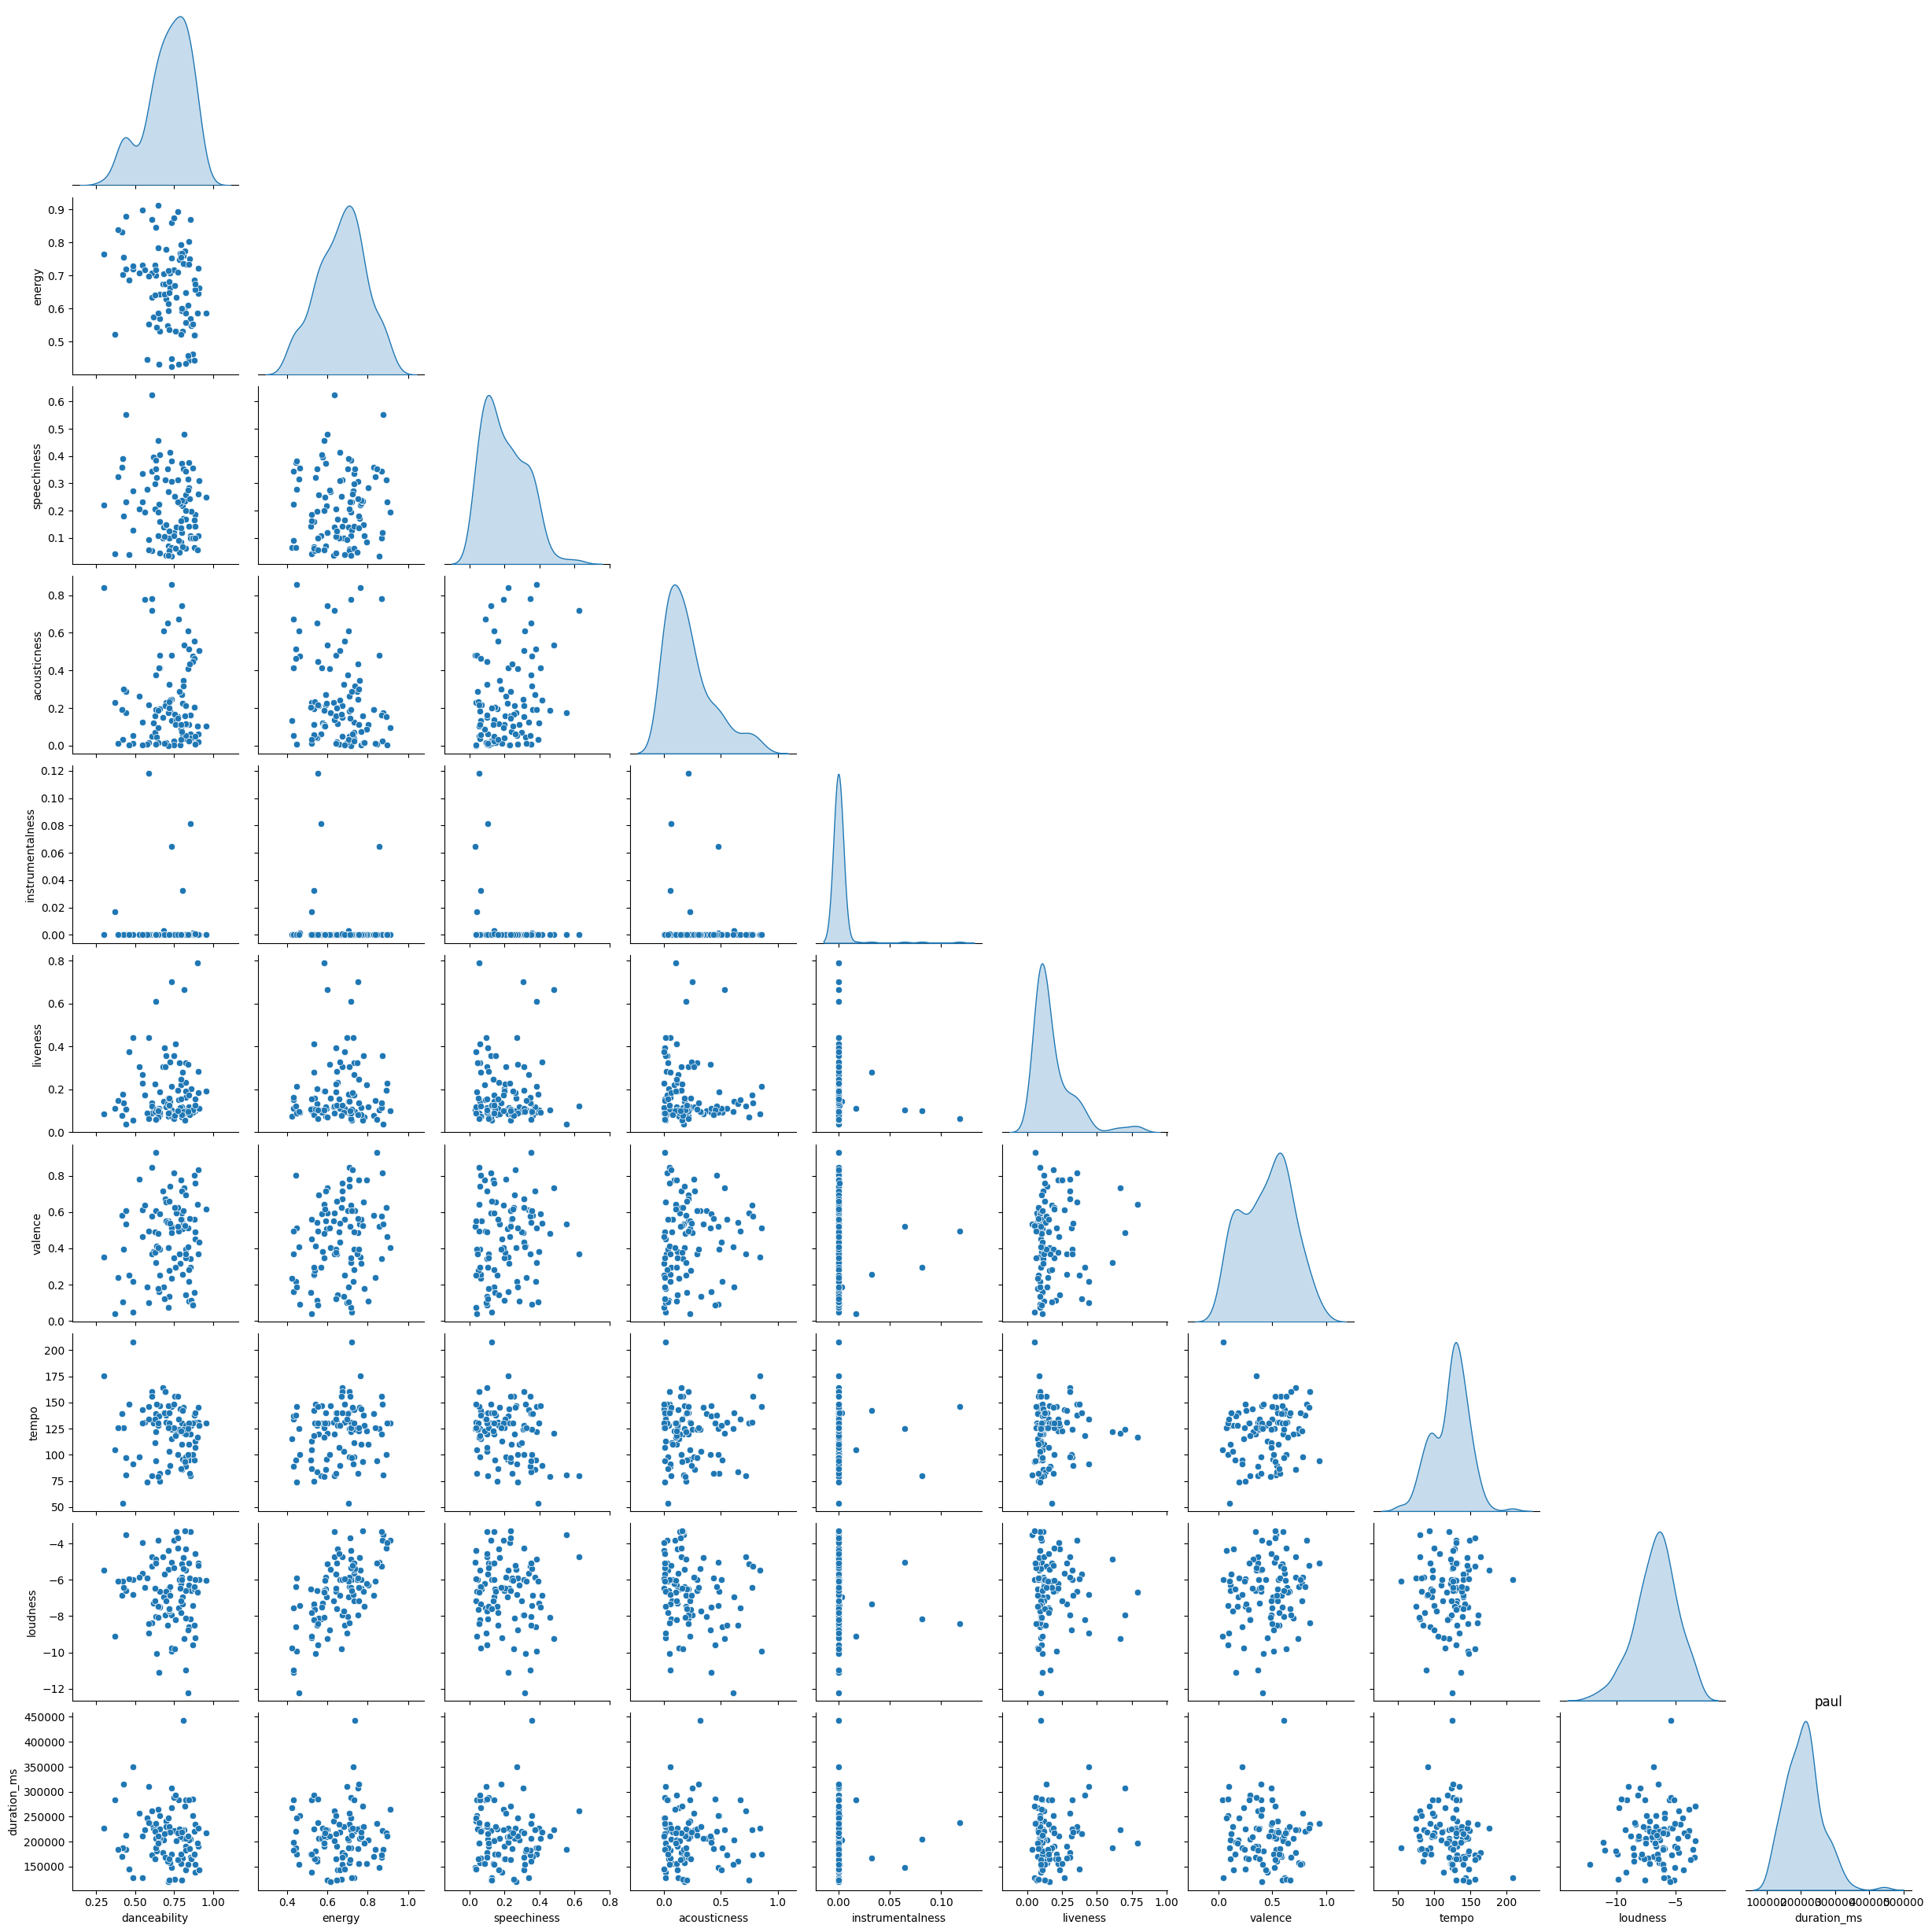

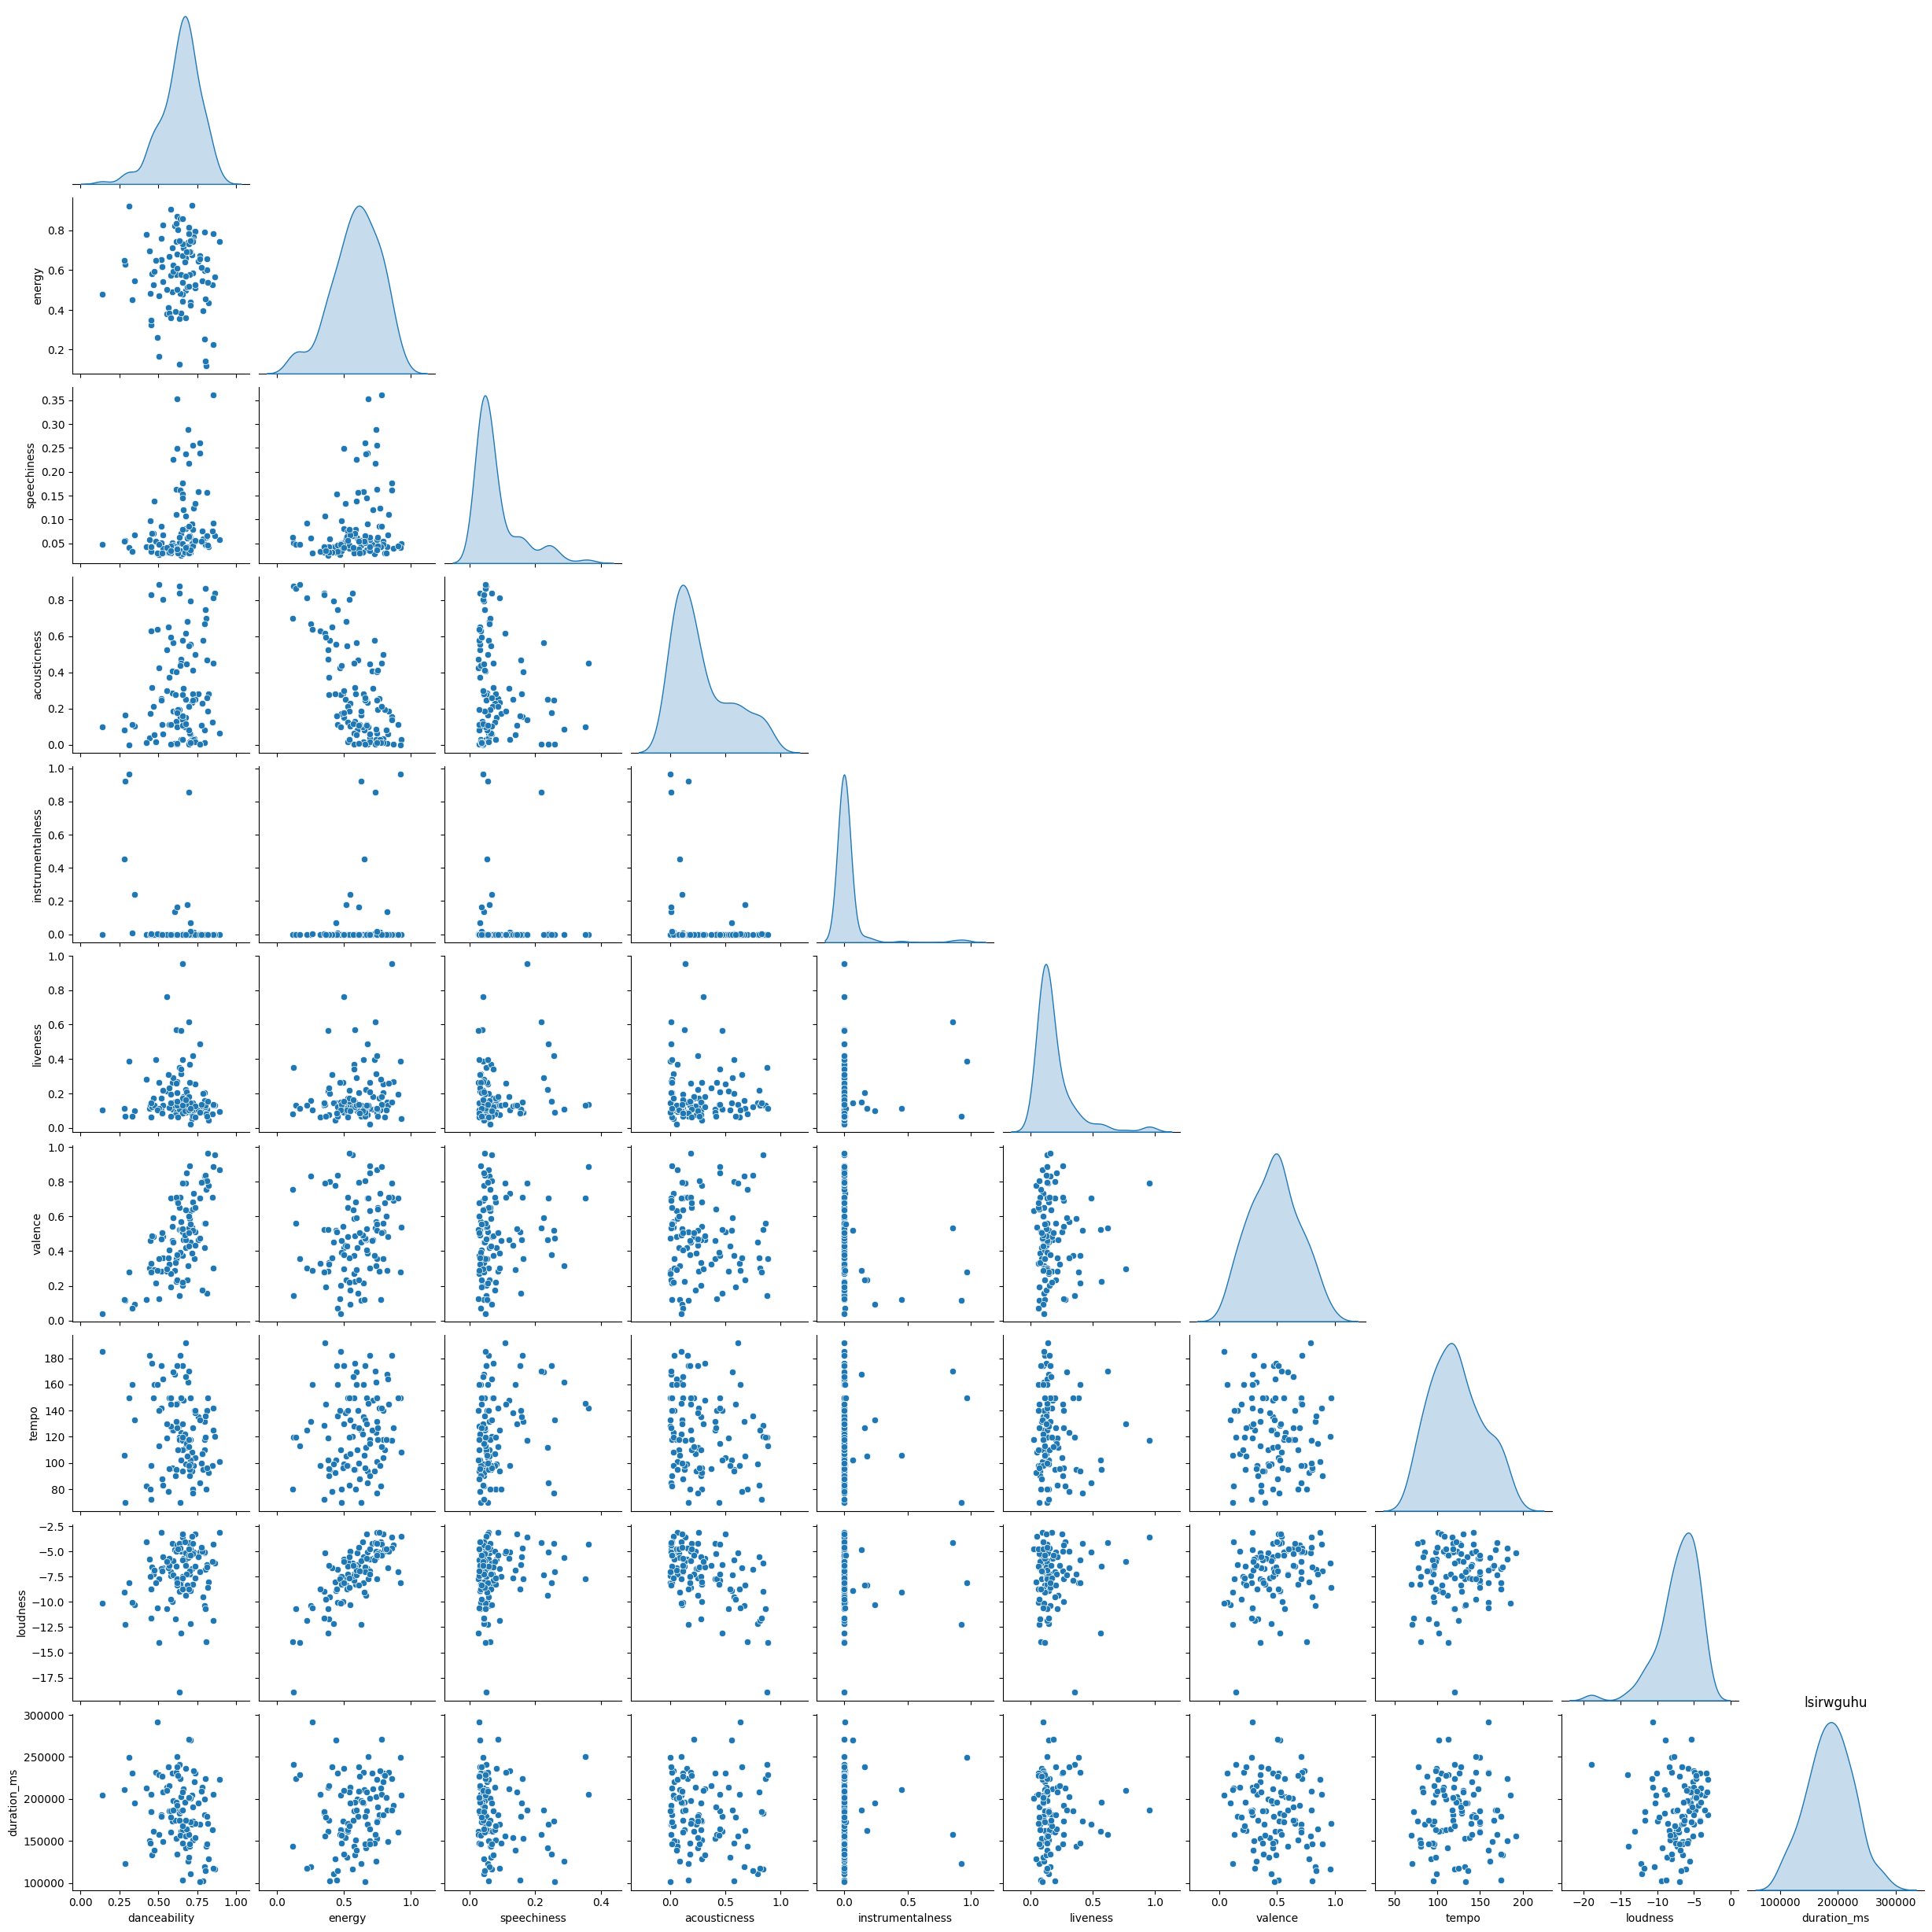

In [14]:
plt.figure(figsize=(20,10))

for i, user in enumerate(USERS):
    # Show features distribution for each user
    user_top_tracks = USERS_DF[i]
    sns.pairplot(user_top_tracks[numeric_features], diag_kind="kde", corner=True)
    plt.title(user.username)